<a href="https://colab.research.google.com/github/winpeperk/dls/blob/main/week_11_GANs/Homework/homework_8_gans_part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1I8kDikouqpH4hf7JBiSYAeNT2IO52T-T" width=600 height=480/></p>
<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Generative adversarial networks</b></h3>



В этом домашнем задании вы обучите GAN генерировать лица людей и посмотрите на то, как можно оценивать качество генерации

In [16]:
import os
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as tt
import torch
import torch.nn as nn
import cv2
from tqdm.notebook import tqdm
from torchvision.utils import save_image
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_theme(style='darkgrid', font_scale=1.2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Часть 1. Подготовка данных (1 балл)

В качестве обучающей выборки возьмем часть датасета [Flickr Faces](https://github.com/NVlabs/ffhq-dataset), который содержит изображения лиц людей в высоком разрешении (1024х1024). Оригинальный датасет очень большой, поэтому мы возьмем его часть. Скачать датасет можно [здесь](https://www.kaggle.com/datasets/tommykamaz/faces-dataset-small?resource=download-directory) и  [здесь](https://drive.google.com/file/d/1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x/view?usp=drive_link)

Давайте загрузим наши изображения. Напишите функцию, которая строит DataLoader для изображений, при этом меняя их размер до нужного значения (размер 1024 слишком большой, поэтому мы рекомендуем взять размер 128 либо немного больше)

In [2]:
import kagglehub

DATA_DIR = kagglehub.dataset_download("tommykamaz/faces-dataset-small")
print(DATA_DIR)
print(os.listdir(DATA_DIR))

100%|██████████| 3.99G/3.99G [01:55<00:00, 37.0MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/tommykamaz/faces-dataset-small/versions/1
['faces_dataset_small']


In [4]:
def get_dataloader(image_size, batch_size):
  """
  Builds dataloader for training data.
  Use tt.Compose and tt.Resize for transformations
  :param image_size: height and wdith of the image
  :param batch_size: batch_size of the dataloader
  :returns: DataLoader object
  """
  stats = (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)

  train_ds = ImageFolder(DATA_DIR, transform=tt.Compose([
    tt.Resize(image_size),
    tt.ToTensor(),
    tt.Normalize(*stats)]))

  train_dl = DataLoader(train_ds, batch_size, shuffle=True, num_workers=2, pin_memory=True)
  return train_dl

In [5]:
image_size = 128
batch_size = 64
#TODO: build dataloader and transfer it to device

train_dataloader = get_dataloader(image_size, batch_size)

## Часть 2. Построение и обучение модели (4 балла)

Сконструируйте генератор и дискриминатор. Помните, что:
* дискриминатор принимает на вход изображение (тензор размера `3 x image_size x image_size`) и выдает вероятность того, что изображение настоящее (тензор размера 1)

* генератор принимает на вход тензор шумов размера `latent_size x 1 x 1` и генерирует изображение размера `3 x image_size x image_size`

In [30]:
discriminator = nn.Sequential(
    # in: 3 x 128 x 128

    nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(32),
    nn.LeakyReLU(0.2, inplace=True),
    # out: 32 x 64 x 64

    nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(64),
    nn.LeakyReLU(0.2, inplace=True),
    # out: 64 x 32 x 32

    nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(128),
    nn.LeakyReLU(0.2, inplace=True),
    # out: 128 x 16 x 16

    nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(256),
    nn.LeakyReLU(0.2, inplace=True),
    # out: 256 x 8 x 8

    nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(512),
    nn.LeakyReLU(0.2, inplace=True),
    # out: 512 x 4 x 4

    nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=0, bias=False),
    # out: 1 x 1 x 1

    nn.Flatten(),
    nn.Sigmoid())

In [31]:
latent_size = 128

In [32]:
generator = nn.Sequential(
    # in: latent_size x 1 x 1

    nn.ConvTranspose2d(latent_size, 512, kernel_size=4, stride=1, padding=0, bias=False),
    nn.BatchNorm2d(512),
    nn.ReLU(True),
    # out: 512 x 4 x 4

    nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(256),
    nn.ReLU(True),
    # out: 256 x 8 x 8

    nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(128),
    nn.ReLU(True),
    # out: 128 x 16 x 16

    nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(True),
    # out: 64 x 32 x 32

    nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(32),
    nn.ReLU(True),
    # out: 32 x 64 x 64

    nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1, bias=False),
    nn.Tanh()
    # out: 3 x 128 x 128
)

Перейдем теперь к обучению нашего GANа. Алгоритм обучения следующий:
1. Учим дискриминатор:
  * берем реальные изображения и присваиваем им метку 1
  * генерируем изображения генератором и присваиваем им метку 0
  * обучаем классификатор на два класса

2. Учим генератор:
  * генерируем изображения генератором и присваиваем им метку 0
  * предсказываем дискриминаторором, реальное это изображение или нет


В качестве функции потерь берем бинарную кросс-энтропию

In [72]:
lr = 0.0001

model = {
    "discriminator": discriminator,
    "generator": generator
}

criterion = {
    "discriminator": nn.BCELoss(),
    "generator": nn.BCELoss()
}

In [73]:
def fit(model, criterion, lr, max_epochs=5, start_idx=1):
    discriminator = model["discriminator"].to(device)
    generator = model["generator"].to(device)

    discriminator.train()
    generator.train()

    torch.cuda.empty_cache()

    losses_g = []
    losses_d = []
    real_scores = []
    fake_scores = []

    optimizer_d = torch.optim.AdamW(
        discriminator.parameters(),
        lr=0.00001,
        betas=(0.5, 0.999)
    )

    optimizer_g = torch.optim.AdamW(
        generator.parameters(),
        lr=lr,
        betas=(0.5, 0.999)
    )

    for epoch in range(max_epochs):
        loss_d_per_epoch = []
        loss_g_per_epoch = []
        real_score_per_epoch = []
        fake_score_per_epoch = []

        for real_images, _ in tqdm(train_dataloader):
            real_images = real_images.to(device, non_blocking=True)
            cur_batch_size = real_images.size(0)

            # train discriminator
            optimizer_d.zero_grad()

            real_preds = discriminator(real_images)
            real_targets = torch.ones(cur_batch_size, 1, device=device)
            real_loss = criterion["discriminator"](real_preds, real_targets)

            latent = torch.randn(cur_batch_size, latent_size, 1, 1, device=device)
            fake_images = generator(latent)

            fake_preds = discriminator(fake_images.detach())
            fake_targets = torch.zeros(cur_batch_size, 1, device=device)
            fake_loss = criterion["discriminator"](fake_preds, fake_targets)

            loss_d = real_loss + fake_loss
            loss_d.backward()
            optimizer_d.step()

            # train generator
            optimizer_g.zero_grad()

            latent = torch.randn(cur_batch_size, latent_size, 1, 1, device=device)
            fake_images = generator(latent)

            preds = discriminator(fake_images)
            targets = torch.ones(cur_batch_size, 1, device=device)

            loss_g = criterion["generator"](preds, targets)
            loss_g.backward()
            optimizer_g.step()

            loss_d_per_epoch.append(loss_d.item())
            loss_g_per_epoch.append(loss_g.item())
            real_score_per_epoch.append(real_preds.mean().item())
            fake_score_per_epoch.append(fake_preds.mean().item())

        losses_g.append(np.mean(loss_g_per_epoch))
        losses_d.append(np.mean(loss_d_per_epoch))
        real_scores.append(np.mean(real_score_per_epoch))
        fake_scores.append(np.mean(fake_score_per_epoch))

        print(
            f"Epoch {epoch + 1}/{max_epochs} | "
            f"loss_g: {losses_g[-1]:.4f} | "
            f"loss_d: {losses_d[-1]:.4f} | "
            f"real_score: {real_scores[-1]:.4f} | "
            f"fake_score: {fake_scores[-1]:.4f}"
        )

    return losses_g, losses_d, real_scores, fake_scores

In [74]:
losses_g, losses_d, real_scores, fake_scores = fit(model, criterion, lr)

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1/5 | loss_g: 3.9164 | loss_d: 2.5184 | real_score: 0.9821 | fake_score: 0.7541


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 2/5 | loss_g: 1.7575 | loss_d: 1.5438 | real_score: 0.8882 | fake_score: 0.5709


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 3/5 | loss_g: 2.2843 | loss_d: 0.7378 | real_score: 0.8938 | fake_score: 0.3367


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 4/5 | loss_g: 2.5685 | loss_d: 0.5700 | real_score: 0.8947 | fake_score: 0.2728


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 5/5 | loss_g: 2.8315 | loss_d: 0.2792 | real_score: 0.9344 | fake_score: 0.1470


Постройте графики лосса для генератора и дискриминатора. Что вы можете сказать про эти графики?

In [75]:
def plot_history(losses_g, losses_d, real_scores, fake_scores):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(losses_g, label='Generator loss')
    axes[0].plot(losses_d, label='Discriminator loss')
    axes[0].set_xlabel('Epoch'), axes[0].set_ylabel('Loss')
    axes[0].set_title('Generator and Discriminator Losses')
    axes[0].legend()

    axes[1].plot(real_scores, label='Real score')
    axes[1].plot(fake_scores, label='Fake score')
    axes[1].set_xlabel('Epoch'), axes[1].set_ylabel('Score')
    axes[1].set_title('Real and Fake Scores')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

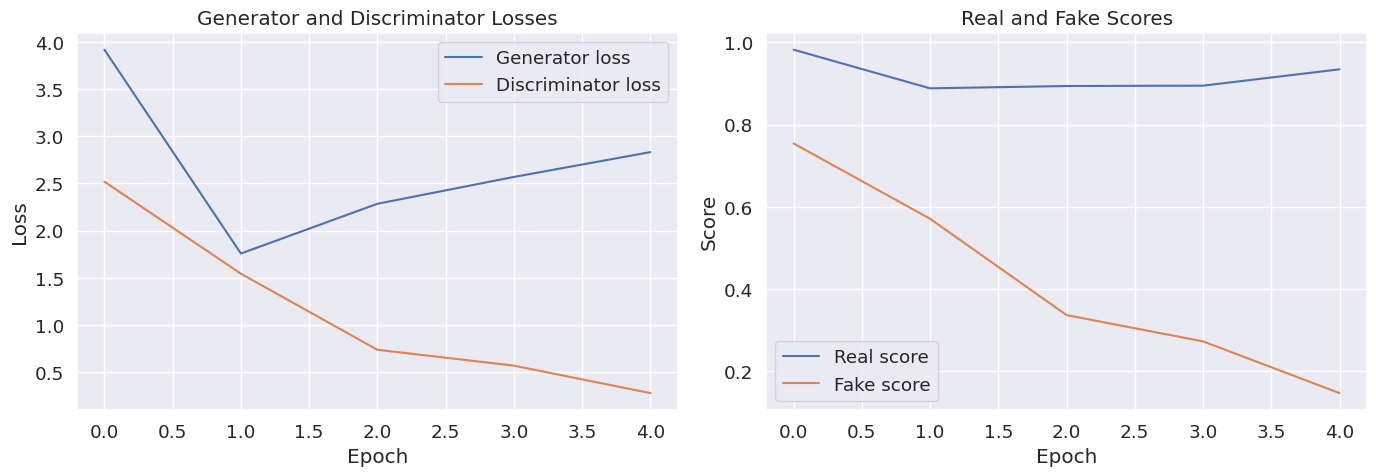

In [76]:
plot_history(losses_g, losses_d, real_scores, fake_scores)

`Вывод`: Изначально наш дискриминатор плохо отличал фейковые картинки от настояших, то есть генератору удавалось его обманывать. К концу обучения баланс смещается в сторону дискриминатора: он научился отличать картинки и fake_score стабильно падает.

## Часть 3. Генерация изображений

Теперь давайте оценим качество получившихся изображений. Напишите функцию, которая выводит изображения, сгенерированные нашим генератором

In [80]:
n_images = 4
stats = (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)

fixed_latent = torch.randn(n_images, latent_size, 1, 1, device=device)
fake_images = model["generator"](fixed_latent)

In [81]:
def denorm(img_tensors):
    return img_tensors * stats[1][0] + stats[0][0]

def show_images(generated, nrow=4):
    generated = generated.detach().cpu()
    generated = denorm(generated)

    grid = make_grid(generated, nrow=nrow)

    plt.figure(figsize=(8, 8))
    plt.axis("off")
    plt.imshow(grid.permute(1, 2, 0))
    plt.show()

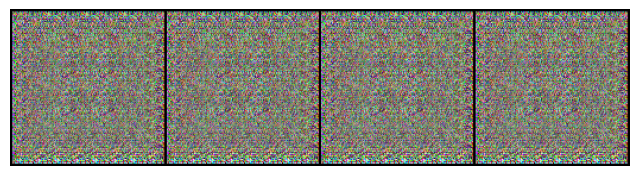

In [82]:
show_images(fake_images, nrow=4)

Как вам качество получившихся изображений?

`Вывод`: Фотографии совсем не похожи на лица людей, сейчас это просто шум.

## Часть 4. Leave-one-out-1-NN classifier accuracy (5 баллов)

### 4.1. Подсчет accuracy (3 балл)

Не всегда бывает удобно оценивать качество сгенерированных картинок глазами. В качестве альтернативы вам предлагается реализовать следующий подход:
  * Сгенерировать столько же фейковых изображений, сколько есть настоящих в обучающей выборке. Присвоить фейковым метку класса 0, настоящим – 1.
  * Построить leave-one-out оценку: обучить 1NN Classifier (`sklearn.neighbors.KNeighborsClassifier(n_neighbors=1)`) предсказывать класс на всех объектах, кроме одного, проверить качество (accuracy) на оставшемся объекте. В этом вам поможет `sklearn.model_selection.LeaveOneOut`

In [100]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_score

def get_real_images(dataloader, n_images=100):
    real_images = []

    for images, _ in dataloader:
        images = images.to(device)
        real_images.append(images)

        if sum(batch.size(0) for batch in real_images) >= n_images:
            break

    real_images = torch.cat(real_images, dim=0)
    return real_images[:n_images]


def get_fake_images(generator, n_images=100):
    generator.eval()

    with torch.no_grad():
        latent = torch.randn(n_images, latent_size, 1, 1, device=device)
        fake_images = generator(latent)

    return fake_images

In [101]:
def accuracy_loo(generator, dataloader, n_images=100):
    real_images = get_real_images(dataloader, n_images)
    fake_images = get_fake_images(generator, n_images)

    real_vectors = real_images.detach().cpu().view(n_images, -1).numpy()
    fake_vectors = fake_images.detach().cpu().view(n_images, -1).numpy()

    X = np.concatenate([fake_vectors, real_vectors], axis=0)

    y = np.concatenate([np.zeros(n_images), np.ones(n_images)])

    clf = KNeighborsClassifier(n_neighbors=1)
    loo = LeaveOneOut()

    scores = cross_val_score(clf, X, y, cv=loo)
    accuracy = scores.mean()

    print(f"Accuracy: {accuracy:.4f}")

    return accuracy

In [102]:
accuracy = accuracy_loo(model["generator"], train_dataloader, n_images=300)

Accuracy: 1.0000


Что вы можете сказать о получившемся результате? Какой accuracy мы хотели бы получить и почему?

`Вывод`:  

1NN-классификатор идеально отличил настоящие изображения от сгенерированных. Это плохой результат, так как фейковые картинки слишком сильно отличаются от реальных.  

В идеале мы хотели бы получить accuracy = 0.5, так как это означало бы, что генератор делает изображения, похожие на настоящие. Классификатору должно быть сложно понять, где real, а где fake.

### 4.2. Визуализация распределений (2 балл)

Давайте посмотрим на то, насколько похожи распределения настоящих и фейковых изображений. Для этого воспользуйтесь методом, снижающим размерность (к примеру, TSNE) и изобразите на графике разным цветом точки, соответствующие реальным и сгенерированным изображенияи

In [106]:
from sklearn.manifold import TSNE

def get_real_images(dataloader, n_images):
    real_images = []

    for images, _ in dataloader:
        images = images.to(device)
        real_images.append(images)

        if sum(x.size(0) for x in real_images) >= n_images:
            break

    real_images = torch.cat(real_images, dim=0)
    return real_images[:n_images]

def get_fake_images(generator, n_images):
    generator.eval()

    fake_images = []

    with torch.no_grad():
        latent = torch.randn(n_images, latent_size, 1, 1, device=device)
        fake_images = generator(latent)

    return fake_images

def plot_tsne(generator, dataloader, n_images=300):
    real_images = get_real_images(dataloader, n_images)
    fake_images = get_fake_images(generator, n_images)

    real_vectors = real_images.detach().cpu().view(n_images, -1).numpy()
    fake_vectors = fake_images.detach().cpu().view(n_images, -1).numpy()

    X = np.concatenate([real_vectors, fake_vectors], axis=0)

    labels = np.concatenate([np.ones(n_images), np.zeros(n_images)])

    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_2d = tsne.fit_transform(X)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_2d[labels == 1, 0], X_2d[labels == 1, 1], label="Real images", alpha=0.6)
    plt.scatter(X_2d[labels == 0, 0], X_2d[labels == 0, 1], label="Fake images", alpha=0.6)

    plt.title("t-SNE: Real vs Fake images")
    plt.legend()
    plt.show()

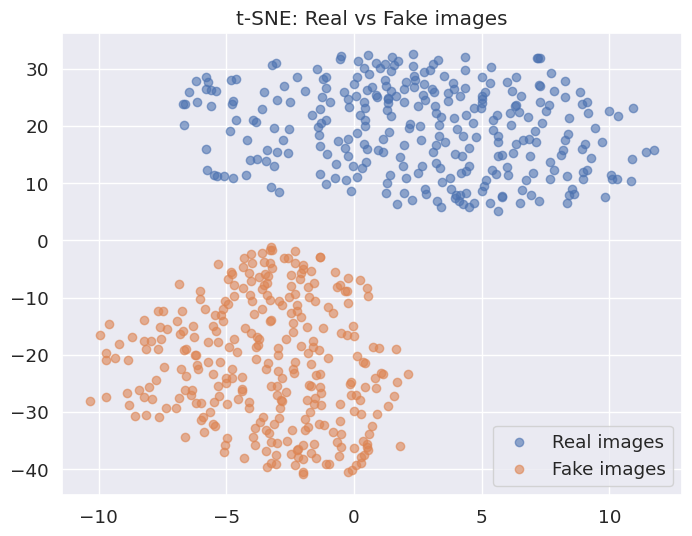

In [107]:
plot_tsne(model["generator"], train_dataloader, n_images=300)

Прокомментируйте получившийся результат:

`Вывод`: По графику t-SNE видно, что распределения real и fake почти полностью разделены. Это означает, что сгенерированные фотографии сильно отличаются от настоящих.